# Supplementary Python Code: Network-Extended TPB for Digital Collaboration in Construction Project Management

This notebook reproduces the quantitative outputs used in the manuscript submitted to the **ASCE Journal of Management in Engineering**.

**Dataset Usage and Citation:**
The data presented in this notebook are the property of their respective owners and are used with prior permission. Any use of this dataset in future work requires prior approval from the corresponding author (Dr. Long D. Nguyen at lnguyen@fgcu.edu). Users must ensure appropriate attribution and citation in all resulting publications or materials.

The workflow produces Tables 1-8 and Figures 2-3 from the manuscript.

## Important SEM reproducibility note

The manuscript mediation SEM frees the covariance between the two exogenous predictors:

```text
SNS ~~ years_pm_experience
```

This is why the manuscript SEM fit table has **df = 17**. If this covariance is omitted, the model imposes an additional zero-covariance restriction between social network support and project management experience, giving **df = 18** and slightly different fit/path results. The diagnostic cell below fits both versions so reviewers can verify the source of the difference.

In [1]:
# Run this cell in Google Colab or a fresh Python environment.
import importlib.util
import subprocess
import sys

INSTALL_MISSING_PACKAGES = True
required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "openpyxl": "openpyxl",
    "scipy": "scipy",
    "statsmodels": "statsmodels",
    "matplotlib": "matplotlib",
    "semopy": "semopy",
    "requests": "requests",
}
if INSTALL_MISSING_PACKAGES:
    missing = [pip_name for import_name, pip_name in required_packages.items() if importlib.util.find_spec(import_name) is None]
    if missing:
        print("Installing missing packages:", missing)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("All required packages are already installed.")

All required packages are already installed.


In [2]:
from pathlib import Path
from io import BytesIO
import platform
import warnings
import numpy as np
import pandas as pd
import requests
from IPython.display import display
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, f
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from semopy import Model, calc_stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

DATA_SHEET = "data"
GOOGLE_SHEETS_URL = "https://docs.google.com/spreadsheets/d/1LgCYpExa7zKLte39pOPM5caEIPdXBB7i/edit?usp=sharing&ouid=115000262379760613029&rtpof=true&sd=true"
GOOGLE_SHEETS_FILE_ID = "1LgCYpExa7zKLte39pOPM5caEIPdXBB7i"
GOOGLE_SHEETS_EXPORT_URL = f"https://docs.google.com/spreadsheets/d/{GOOGLE_SHEETS_FILE_ID}/export?format=xlsx"
OUTPUT_DIR = Path("outputs_network_extended_tpb")
OUTPUT_DIR.mkdir(exist_ok=True)
RANDOM_SEED = 123
N_BOOTSTRAP = 20000
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
try:
    import semopy
    print("semopy:", semopy.__version__)
except Exception:
    pass
print("Dataset source:", GOOGLE_SHEETS_URL)


Python: 3.13.9
pandas: 2.3.3
semopy: 2.3.11
Dataset source: https://docs.google.com/spreadsheets/d/1LgCYpExa7zKLte39pOPM5caEIPdXBB7i/edit?usp=sharing&ouid=115000262379760613029&rtpof=true&sd=true


## 1. Load dataset directly from Google Drive/Sheets

This notebook always reads the dataset from the Google Drive/Sheets link.


In [4]:
def load_google_sheet_xlsx(export_url, preferred_sheet="data"):
    """Download the latest Google Sheets/Drive spreadsheet as an Excel workbook and load it into pandas.

    The workbook is kept in memory using BytesIO. No local data file is read or written.
    """
    response = requests.get(export_url, timeout=90)
    content_type = response.headers.get("Content-Type", "")

    if response.status_code != 200:
        raise RuntimeError(
            f"Google Drive/Sheets download failed with status {response.status_code}. "
            "Check that the file is shared as 'Anyone with the link can view'."
        )

    first_bytes = response.content[:1000].lower()
    if b"<html" in first_bytes or "text/html" in content_type.lower():
        raise RuntimeError(
            "Google returned an HTML page instead of an Excel workbook. "
            "Set the spreadsheet permission to 'Anyone with the link can view', then rerun the notebook."
        )

    workbook_bytes = BytesIO(response.content)
    excel_file = pd.ExcelFile(workbook_bytes)
    print("Available sheets:", excel_file.sheet_names)

    sheet_to_read = preferred_sheet if preferred_sheet in excel_file.sheet_names else excel_file.sheet_names[0]
    workbook_bytes.seek(0)
    data = pd.read_excel(workbook_bytes, sheet_name=sheet_to_read)
    return data, sheet_to_read

print("Downloading the latest dataset directly from Google Drive/Sheets...")
df, sheet_to_read = load_google_sheet_xlsx(GOOGLE_SHEETS_EXPORT_URL, DATA_SHEET)
print("Sheet read:", sheet_to_read)
print("Data shape:", df.shape)
display(df.head())


Available sheets: ['data', 'codebook', 'summary']
Sheet read: data
Data shape: (210, 38)


,timestamp,job_title,years_experience,years_pm_experience,highest_education_en,prior_formal_training_en,training_details,group_id,att_ai_improves_pm_en,att_ai_improves_pm_num,att_ai_quality_delay_en,att_ai_quality_delay_num,att_open_to_ai_en,att_open_to_ai_num,sn_supervisor_encourage_en,sn_supervisor_encourage_num,sn_colleagues_support_en,sn_colleagues_support_num,sn_people_important_think_should_en,sn_people_important_think_should_num,pbc_access_tools_en,pbc_access_tools_num,pbc_self_efficacy_en,pbc_self_efficacy_num,pbc_time_en,pbc_time_num,support_has_colleague_help_en,support_has_colleague_help_num,team_discuss_tech_en,team_discuss_tech_num,support_colleagues_try_new_en,support_colleagues_try_new_num,digital_collaboration_en,digital_collaboration_num,ATT_mean,SN_mean,PBC_mean,SUPPORT_mean
0,2025-09-16 16:05:49.668,Design manager,21.0,11,Postgraduate,Yes,Construction project management at HCMUT,1,Agree,4,Agree,4,Agree,4,Agree,4,Agree,4,Agree,4,Agree,4,Agree,4,Agree,4,Agree,4,Agree,4,Agree,4,Agree,4,4.000000,4.000000,4.000000,4.000000
1,2025-09-17 17:42:33.643,Project Manager,13.0,4,Postgraduate,No,Not yet participated,1,Strongly agree,5,Strongly agree,5,Strongly agree,5,Agree,4,Neutral,3,Agree,4,Agree,4,Agree,4,Neutral,3,Neutral,3,Neutral,3,Neutral,3,Agree,4,5.000000,3.666667,3.666667,3.000000
2,2025-09-17 17:52:27.585,Site supervisor,14.0,10,Bachelor,No,NaN,1,Strongly agree,5,Strongly agree,5,Strongly agree,5,Strongly agree,5,Agree,4,Agree,4,Agree,4,Agree,4,Agree,4,Strongly agree,5,Strongly agree,5,Agree,4,Agree,4,5.000000,4.333333,4.000000,4.666667
3,2025-09-17 18:24:48.892,Chief site supervisor,15.0,10,Bachelor,No,No,1,Strongly agree,5,Strongly agree,5,Agree,4,Strongly agree,5,Agree,4,Agree,4,Agree,4,Agree,4,Agree,4,Agree,4,Agree,4,Agree,4,Agree,4,4.666667,4.333333,4.000000,4.000000
4,2025-09-17 19:32:37.241,Design manager,15.0,2,Bachelor,No,No,1,Agree,4,Agree,4,Strongly agree,5,Agree,4,Agree,4,Agree,4,Agree,4,Agree,4,Neutral,3,Agree,4,Neutral,3,Agree,4,Agree,4,4.333333,4.000000,3.666667,3.666667


## 2. Define variables, normalize translated values, and verify data

The Google Drive dataset contains English-translated text fields. The code below standardizes those translations before analysis so the outputs remain reproducible after values are updated.


In [5]:
CONSTRUCT_ITEMS = {
    "ATT": ["att_ai_improves_pm_num", "att_ai_quality_delay_num", "att_open_to_ai_num"],
    "SN": ["sn_supervisor_encourage_num", "sn_colleagues_support_num", "sn_people_important_think_should_num"],
    "PBC": ["pbc_access_tools_num", "pbc_self_efficacy_num", "pbc_time_num"],
    "SNS": ["support_has_colleague_help_num", "team_discuss_tech_num", "support_colleagues_try_new_num"],
}
CONSTRUCT_LABELS = {
    "ATT": "Attitude toward AI use in project management (ATT)",
    "SN": "Subjective norm toward AI/digital technology use (SN)",
    "PBC": "Perceived behavioral control over AI/digital technology use (PBC)",
    "SNS": "Social network support for digital/AI technology use (SNS)",
}
ITEM_LABELS = {
    "att_ai_improves_pm_num": "Using AI tools will make my project management more effective (ATT1)",
    "att_ai_quality_delay_num": "AI tools will improve quality and reduce delays (ATT2)",
    "att_open_to_ai_num": "I am open to using AI regularly at work (ATT3)",
    "sn_supervisor_encourage_num": "My supervisor encourages using new digital tools (SN1)",
    "sn_colleagues_support_num": "My colleagues support using AI at work (SN2)",
    "sn_people_important_think_should_num": "People important to me think I should try AI tools (SN3)",
    "pbc_access_tools_num": "I have access to the necessary digital tools for work (PBC1)",
    "pbc_self_efficacy_num": "I feel confident learning and applying AI (PBC2)",
    "pbc_time_num": "I have enough time to explore new technologies (PBC3)",
    "support_has_colleague_help_num": "I have at least one colleague I can get help from about AI/technology (SNS1)",
    "team_discuss_tech_num": "My team often discusses technology tools like AI (SNS2)",
    "support_colleagues_try_new_num": "I feel supported by colleagues to try new tools (SNS3)",
    "digital_collaboration_num": "I often exchange project ideas and collaborate with colleagues using digital tools (DCB)",
}
OUTCOME_VAR = "digital_collaboration_num"
CONTROL_VAR = "years_pm_experience"

# Numeric variables required for the manuscript analyses.
required_columns = sorted({item for items in CONSTRUCT_ITEMS.values() for item in items} | {OUTCOME_VAR, CONTROL_VAR})
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Some Google Drive columns may now contain English Likert labels rather than pure numeric values.
# This converter keeps numeric values when present, but also maps common English/Vietnamese Likert text.
LIKERT_TEXT_TO_NUM = {
    # Agreement scale
    "strongly disagree": 1, "disagree": 2, "neutral": 3, "neither agree nor disagree": 3,
    "agree": 4, "strongly agree": 5,
    # Frequency scale
    "never": 1, "very rarely": 1, "rarely": 2, "occasionally": 3, "sometimes": 3,
    "often": 4, "very often": 5, "always": 5,
    # Vietnamese labels retained for backward compatibility with older copies of the file
    "hoàn toàn không đồng ý": 1, "không đồng ý": 2, "trung lập": 3,
    "đồng ý": 4, "hoàn toàn đồng ý": 5,
    "không bao giờ": 1, "hiếm khi": 2, "thỉnh thoảng": 3, "thường xuyên": 4, "rất thường xuyên": 5,
}

def _clean_text_value(value):
    if pd.isna(value):
        return ""
    text = str(value).strip().lower()
    text = " ".join(text.replace("\u00a0", " ").split())
    return text

def coerce_numeric_or_likert(series, fallback_series=None, column_name=""):
    """Convert a series to numeric, using English/Vietnamese Likert labels when necessary.

    If a *_num column has been translated accidentally or contains text labels, this function
    maps the text to 1-5 values. If that fails and a paired *_en column exists, the paired
    English column is used as a fallback.
    """
    numeric = pd.to_numeric(series, errors="coerce")

    # Map labels in the primary series.
    primary_text = series.map(_clean_text_value)
    mapped_primary = primary_text.map(LIKERT_TEXT_TO_NUM)
    numeric = numeric.fillna(mapped_primary)

    # Handle labels such as "5 - Strongly agree" or "4. Agree".
    extracted = primary_text.str.extract(r"^\s*([1-5])\s*(?:[-.:)]|$)", expand=False)
    numeric = numeric.fillna(pd.to_numeric(extracted, errors="coerce"))

    # Use paired *_en column as a fallback when available.
    if fallback_series is not None:
        fallback_text = fallback_series.map(_clean_text_value)
        mapped_fallback = fallback_text.map(LIKERT_TEXT_TO_NUM)
        fallback_extracted = fallback_text.str.extract(r"^\s*([1-5])\s*(?:[-.:)]|$)", expand=False)
        numeric = numeric.fillna(mapped_fallback).fillna(pd.to_numeric(fallback_extracted, errors="coerce"))

    bad = numeric.notna() & ~numeric.between(1, 5)
    if bad.any():
        print(f"Warning: {column_name or series.name} contains values outside the expected 1-5 range.")

    return numeric

# Convert all analysis variables. For each *_num column, use the paired *_en column if it exists.
for col in required_columns:
    if col == CONTROL_VAR:
        # PM experience is a numeric control; if English labels appear, extract the first number.
        numeric = pd.to_numeric(df[col], errors="coerce")
        if numeric.isna().any():
            extracted = df[col].astype(str).str.extract(r"(-?\d+(?:\.\d+)?)", expand=False)
            numeric = numeric.fillna(pd.to_numeric(extracted, errors="coerce"))
        df[col] = numeric
    else:
        en_col = col.replace("_num", "_en") if col.endswith("_num") else None
        fallback = df[en_col] if en_col in df.columns else None
        df[col] = coerce_numeric_or_likert(df[col], fallback_series=fallback, column_name=col)

# Recalculate construct scores from the standardized numeric items. Do not rely on stale mean columns.
for construct, items in CONSTRUCT_ITEMS.items():
    df[f"{construct}_mean"] = df[items].mean(axis=1)

# Keep the original notebook alias for compatibility with earlier code.
df["SUPPORT_mean"] = df["SNS_mean"]

analysis_vars = ["ATT_mean", "SN_mean", "PBC_mean", "SNS_mean", OUTCOME_VAR, CONTROL_VAR]
print("Missing values in analysis variables after English-value normalization:")
display(df[analysis_vars].isna().sum().to_frame("Missing"))

Missing values in analysis variables after English-value normalization:


,Missing
ATT_mean,0
SN_mean,0
PBC_mean,0
SNS_mean,0
digital_collaboration_num,0
years_pm_experience,0


Digital collaboration numeric distribution after normalization:


,Frequency
digital_collaboration_num,
1,4
2,4
3,59
4,92
5,51


## 3. Utility functions

In [6]:
def cronbach_alpha(items_df):
    """Cronbach's alpha for a set of item columns."""
    items = items_df.apply(pd.to_numeric, errors="coerce").dropna()
    n_items = items.shape[1]
    item_variances = items.var(axis=0, ddof=1)
    total_variance = items.sum(axis=1).var(ddof=1)
    return (n_items / (n_items - 1)) * (1 - item_variances.sum() / total_variance)

def standardize(series):
    return (series - series.mean()) / series.std(ddof=0)

def significance_stars(p):
    if pd.isna(p): return ""
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    if p < 0.10: return "†"
    return ""

def p_value_text(p):
    if pd.isna(p): return ""
    if p < 0.001: return "< .001"
    return f"{p:.3f}"

def sem_std_col(estimates):
    for col in ["Est. Std", "Std. Ests", "Est.Std", "Std.Estimate"]:
        if col in estimates.columns:
            return col
    raise KeyError(f"Could not find standardized-estimate column in {list(estimates.columns)}")

def sem_p_col(estimates):
    for col in ["p-value", "pvalue", "P-value", "P>|z|"]:
        if col in estimates.columns:
            return col
    return None

def fit_value(fit_df, key):
    if "Value" in fit_df.index and key in fit_df.columns:
        return float(fit_df.loc["Value", key])
    if key in fit_df.index and "Value" in fit_df.columns:
        return float(fit_df.loc[key, "Value"])
    if key in fit_df.columns:
        return float(fit_df[key].iloc[0])
    if key in fit_df.index:
        return float(fit_df.loc[key].iloc[0])
    raise KeyError(f"Fit index '{key}' not found. Available rows={list(fit_df.index)}, cols={list(fit_df.columns)}")

def calculate_vif(data, predictors):
    X = sm.add_constant(data[predictors])
    rows = []
    for i, col in enumerate(X.columns):
        if col == "const":
            continue
        rows.append({"Variable": col, "VIF": variance_inflation_factor(X.values, i)})
    return pd.DataFrame(rows)

## 4. Table 1: Respondent profile

This section standardizes English-translated profile fields before creating Table 1. The job-title classifier follows the priority as follows: project/construction management first, then design/engineering/BIM/QS, site supervision, executive/senior management, academic/government/training, and other. This prevents translated titles such as “Project Engineer” or “Construction Project Manager” from being moved into another category simply because they contain the word “engineer” or “manager.”


In [7]:
def normalize_category_text(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    text = " ".join(text.replace("\u00a0", " ").split())
    return text

def normalize_category_key(value):
    return normalize_category_text(value).lower()

ROLE_ORDER = [
    "Design / engineering / BIM / QS",
    "Project / construction management",
    "Executive / senior management",
    "Site supervision / construction execution",
    "Academic / government / training",
    "Other",
]

# Direct mappings are used if the translated Google Drive value is already a broad category.
ROLE_DIRECT_MAP = {
    "design / engineering / bim / qs": "Design / engineering / BIM / QS",
    "design / engineering / bim / quantity surveying": "Design / engineering / BIM / QS",
    "design / engineering / bim / qs": "Design / engineering / BIM / QS",
    "design / engineering / bim/qs": "Design / engineering / BIM / QS",
    "project / construction management": "Project / construction management",
    "project / construction manager": "Project / construction management",
    "project/construction management": "Project / construction management",
    "executive / senior management": "Executive / senior management",
    "executive/senior management": "Executive / senior management",
    "site supervision / construction execution": "Site supervision / construction execution",
    "site supervision / construction": "Site supervision / construction execution",
    "academic / government / training": "Academic / government / training",
    "academic/government/training": "Academic / government / training",
    "other": "Other",
}

def classify_job_title(title):
    """Classify translated job titles into manuscript role categories.

    The order intentionally mirrors the original notebook to preserve Table 1 reproducibility.
    """
    key = normalize_category_key(title)
    if not key:
        return "Other"
    if key in ROLE_DIRECT_MAP:
        return ROLE_DIRECT_MAP[key]

    # 1. Project / construction management. Checked before engineering/executive terms to match original code.
    if any(k in key for k in [
        "project management", "project manager", "project director", "project coordinator", "project engineer",
        "project control", "project controls", "pmo", "pm", "construction management", "construction manager",
        "construction project", "qlda", "ban qlda", "quản lý dự án", "quản lý xây dựng",
    ]):
        return "Project / construction management"

    # 2. Design / engineering / architecture / BIM / QS.
    if any(k in key for k in [
        "design", "designer", "engineering", "engineer", "bim", "quantity surveyor", "quantity surveying",
        "qs", "cost estimator", "estimator", "architect", "architecture", "architectural", "structural",
        "mep", "cad", "draft", "thiết kế", "kỹ sư", "kiến trúc", "dự toán", "kết cấu",
    ]):
        return "Design / engineering / BIM / QS"

    # 3. Site supervision / construction execution.
    if any(k in key for k in [
        "site", "supervisor", "supervision", "site engineer", "site manager", "construction execution",
        "construction site", "field", "foreman", "contractor", "site commander", "chief of construction",
        "giám sát", "gst", "công trường", "chỉ huy", "thi công",
    ]):
        return "Site supervision / construction execution"

    # 4. Executive / senior management / owner side.
    if any(k in key for k in [
        "ceo", "chief executive", "director", "deputy director", "general director", "vice director",
        "chairman", "board", "executive", "senior manager", "manager", "department head", "head of",
        "owner", "investor", "client representative", "giám đốc", "phó tgđ", "tổng giám đốc",
        "chủ tịch", "hđqt", "trưởng phòng",
    ]):
        return "Executive / senior management"

    # 5. Academic / government / training.
    if any(k in key for k in [
        "academic", "lecturer", "professor", "researcher", "university", "faculty", "instructor",
        "teacher", "government", "public agency", "state management", "training", "giảng viên",
        "đào tạo", "quản lý nhà nước",
    ]):
        return "Academic / government / training"

    return "Other"

EDUCATION_ORDER = ["Bachelor", "Postgraduate", "Vocational / intermediate", "College/associate", "Other"]

def standardize_education(value):
    key = normalize_category_key(value)
    if not key or key in {"nan", "missing", "none"}:
        return "Other"
    if any(k in key for k in ["postgraduate", "graduate", "master", "phd", "doctor", "doctoral"]):
        return "Postgraduate"
    if any(k in key for k in ["bachelor", "university", "undergraduate"]):
        return "Bachelor"
    if any(k in key for k in ["vocational", "intermediate"]):
        return "Vocational / intermediate"
    if any(k in key for k in ["college", "associate"]):
        return "College/associate"
    return "Other"

YES_NO_ORDER = ["No", "Yes", "Other"]

def standardize_yes_no(value):
    key = normalize_category_key(value)
    if not key or key in {"nan", "missing", "none", "n/a", "na", "no formal training", "no training"}:
        return "No"
    if key in {"yes", "y", "true", "1", "có", "co"} or key.startswith("yes"):
        return "Yes"
    if key in {"no", "n", "false", "0", "không", "khong"} or key.startswith("no"):
        return "No"
    return "Other"

def derive_prior_training(data):
    """Create Yes/No training status from the best available translated field.

    Prefer prior_formal_training_en if it exists. If not, derive from training_details.
    This matters because training_details was translated and may now contain English text such as
    'None', 'No formal training', or a description of a course/workshop.
    """
    if "prior_formal_training_en" in data.columns:
        return data["prior_formal_training_en"].map(standardize_yes_no)
    if "training_details" in data.columns:
        details = data["training_details"].map(normalize_category_key)
        no_training = details.isin(["", "nan", "none", "n/a", "na", "no", "no formal training", "no training"])
        return np.where(no_training, "No", "Yes")
    return pd.Series(["Other"] * len(data), index=data.index)

def profile_table_from_series(series, ordered_categories=None, label=""):
    clean = pd.Series(series, index=df.index).copy()
    if ordered_categories is not None:
        clean = pd.Categorical(clean, categories=ordered_categories, ordered=True)
        counts = pd.Series(clean).value_counts(dropna=False, sort=False)
    else:
        counts = pd.Series(clean).value_counts(dropna=False)
    out = counts.rename_axis("Description").reset_index(name="Frequency")
    out["Percent (%)"] = out["Frequency"] / len(df) * 100
    out.insert(0, "Variable", label)
    # Remove zero-frequency categories to keep the manuscript table concise.
    out = out[out["Frequency"] > 0].reset_index(drop=True)
    return out

def numeric_summary_row(data, column, label):
    x = pd.to_numeric(data[column], errors="coerce") if column in data.columns else pd.Series(dtype=float)
    if x.notna().sum() == 0:
        value = "No valid numeric data"
    else:
        value = f"{x.mean():.2f} ({x.std(ddof=1):.2f}); {x.min():.0f}-{x.max():.0f}"
    return pd.DataFrame({"Variable": [label], "Description": ["Mean (SD); Min-Max"], "Frequency": [value], "Percent (%)": [""]})

# Standardized profile variables. These are derived from the English-translated Google Drive data.
df["role_category"] = df.get("job_title", pd.Series(index=df.index, dtype="object")).map(classify_job_title)
df["education_category"] = df.get("highest_education_en", pd.Series(index=df.index, dtype="object")).map(standardize_education)
df["prior_training_category"] = derive_prior_training(df)

pm_bins = [-0.001, 2, 5, 10, 15, np.inf]
pm_labels = ["0-2 years", "3-5 years", "6-10 years", "11-15 years", "More than 15 years"]
df["pm_experience_category"] = pd.cut(df[CONTROL_VAR], bins=pm_bins, labels=pm_labels)

# Manuscript Table 1: matches the respondent-profile structure used in the manuscript.
profile_parts = [
    profile_table_from_series(df["role_category"], ROLE_ORDER, "Professional role / job category"),
    profile_table_from_series(df["education_category"], EDUCATION_ORDER, "Highest education"),
    profile_table_from_series(df["pm_experience_category"], pm_labels, "PM experience"),
]
table1 = pd.concat(profile_parts, ignore_index=True)
table1["Percent (%)"] = table1["Percent (%)"].round(1)

# A fuller supplementary version, retained because the original notebook also summarized training and experience.
full_profile_parts = [
    pd.DataFrame({"Variable": ["Sample size"], "Description": ["Total valid responses"], "Frequency": [len(df)], "Percent (%)": [100.0]}),
    profile_table_from_series(df["role_category"], ROLE_ORDER, "Professional role / job category"),
    profile_table_from_series(df["education_category"], EDUCATION_ORDER, "Highest education"),
    profile_table_from_series(df["prior_training_category"], YES_NO_ORDER, "Prior formal AI / digital training"),
]
if "group_id" in df.columns:
    full_profile_parts.append(profile_table_from_series(df["group_id"], None, "Survey group"))
if "years_experience" in df.columns:
    full_profile_parts.append(numeric_summary_row(df, "years_experience", "Total work experience"))
full_profile_parts.append(numeric_summary_row(df, CONTROL_VAR, "PM experience"))
if "years_experience" in df.columns:
    total_exp_bins = [-0.001, 5, 10, 15, 20, np.inf]
    total_exp_labels = ["0-5 years", "6-10 years", "11-15 years", "16-20 years", "More than 20 years"]
    df["total_experience_category"] = pd.cut(pd.to_numeric(df["years_experience"], errors="coerce"), bins=total_exp_bins, labels=total_exp_labels)
    full_profile_parts.append(profile_table_from_series(df["total_experience_category"], total_exp_labels, "Total work experience"))
full_profile_parts.append(profile_table_from_series(df["pm_experience_category"], pm_labels, "PM experience"))
table1_full_profile = pd.concat(full_profile_parts, ignore_index=True)
table1_full_profile["Percent (%)"] = table1_full_profile["Percent (%)"].apply(lambda x: "" if x == "" else round(float(x), 1))

print("Manuscript Table 1:")
display(table1)
print("Supplementary/full respondent profile table:")
display(table1_full_profile)
print("Role-category check from translated job_title values:")
display(df[["job_title", "role_category"]].head(20) if "job_title" in df.columns else df[["role_category"]].head(20))


Manuscript Table 1:


,Variable,Description,Frequency,Percent (%)
0,Professional role / job category,Design / engineering / BIM / QS,54,25.7
1,Professional role / job category,Project / construction management,58,27.6
2,Professional role / job category,Executive / senior management,39,18.6
3,Professional role / job category,Site supervision / construction execution,11,5.2
4,Professional role / job category,Academic / government / training,5,2.4
5,Professional role / job category,Other,43,20.5
6,Highest education,Bachelor,143,68.1
7,Highest education,Postgraduate,65,31.0
8,Highest education,Vocational / intermediate,1,0.5
9,Highest education,College/associate,1,0.5


Supplementary/full respondent profile table:


,Variable,Description,Frequency,Percent (%)
0,Sample size,Total valid responses,210,100.0
1,Professional role / job category,Design / engineering / BIM / QS,54,25.7
2,Professional role / job category,Project / construction management,58,27.6
3,Professional role / job category,Executive / senior management,39,18.6
4,Professional role / job category,Site supervision / construction execution,11,5.2
5,Professional role / job category,Academic / government / training,5,2.4
6,Professional role / job category,Other,43,20.5
7,Highest education,Bachelor,143,68.1
8,Highest education,Postgraduate,65,31.0
9,Highest education,Vocational / intermediate,1,0.5


Role-category check from translated job_title values:


,job_title,role_category
0,Design manager,Design / engineering / BIM / QS
1,Project Manager,Project / construction management
2,Site supervisor,Site supervision / construction execution
3,Chief site supervisor,Site supervision / construction execution
4,Design manager,Design / engineering / BIM / QS
5,CEO,Executive / senior management
6,Site Supervisor-Consultant,Site supervision / construction execution
7,Site Supervisor-Consultant,Site supervision / construction execution
8,CM,Other
9,Head of In-house Training Department,Executive / senior management


## 5. Table 2: Measurement items and descriptive statistics

In [8]:
rows = []
for construct, items in CONSTRUCT_ITEMS.items():
    mean_col = f"{construct}_mean"
    rows.append({"Construct / Variable": CONSTRUCT_LABELS[construct], "Mean": df[mean_col].mean(), "SD": df[mean_col].std(ddof=1), "Level": "Construct"})
    for item in items:
        rows.append({"Construct / Variable": "     " + ITEM_LABELS[item], "Mean": df[item].mean(), "SD": df[item].std(ddof=1), "Level": "Item"})
rows.append({"Construct / Variable": "Digital collaboration behavior (DCB)", "Mean": df[OUTCOME_VAR].mean(), "SD": df[OUTCOME_VAR].std(ddof=1), "Level": "Observed outcome"})
rows.append({"Construct / Variable": "     " + ITEM_LABELS[OUTCOME_VAR], "Mean": df[OUTCOME_VAR].mean(), "SD": df[OUTCOME_VAR].std(ddof=1), "Level": "Item"})
table2 = pd.DataFrame(rows)
table2_display = table2[["Construct / Variable", "Mean", "SD"]].copy()
table2_display[["Mean", "SD"]] = table2_display[["Mean", "SD"]].round(2)
display(table2_display)

,Construct / Variable,Mean,SD
0,Attitude toward AI use in project management (...,4.34,0.70
1,Using AI tools will make my project manag...,4.37,0.74
2,AI tools will improve quality and reduce ...,4.31,0.77
3,I am open to using AI regularly at work (...,4.34,0.80
4,Subjective norm toward AI/digital technology u...,4.20,0.71
5,My supervisor encourages using new digita...,4.21,0.79
6,My colleagues support using AI at work (SN2),4.15,0.79
7,People important to me think I should try...,4.24,0.80
8,Perceived behavioral control over AI/digital t...,4.19,0.70
9,I have access to the necessary digital to...,4.32,0.71


## 6. Table 3: Reliability and convergent validity

In [9]:
def fit_measurement_model(df):
    measurement_model_desc = """
    ATT =~ att_ai_improves_pm_num + att_ai_quality_delay_num + att_open_to_ai_num
    SN =~ sn_supervisor_encourage_num + sn_colleagues_support_num + sn_people_important_think_should_num
    PBC =~ pbc_access_tools_num + pbc_self_efficacy_num + pbc_time_num
    SNS =~ support_has_colleague_help_num + team_discuss_tech_num + support_colleagues_try_new_num
    """
    model_vars = [item for items in CONSTRUCT_ITEMS.values() for item in items]
    data = df[model_vars].apply(pd.to_numeric, errors="coerce").dropna().copy()
    model = Model(measurement_model_desc)
    model.fit(data)
    estimates = model.inspect(std_est=True)
    return model, data, estimates

def calculate_cr_ave(loadings_df, std_col):
    rows = []
    for construct, group in loadings_df.groupby("Construct"):
        lambdas = group[std_col].astype(float).abs().values
        squared_loadings = lambdas ** 2
        error_variances = 1 - squared_loadings
        cr = (np.sum(lambdas) ** 2) / ((np.sum(lambdas) ** 2) + np.sum(error_variances))
        ave = np.sum(squared_loadings) / len(lambdas)
        rows.append({"Construct": construct, "Items": len(lambdas), "Composite Reliability": cr, "AVE": ave, "Min loading": np.min(lambdas), "Max loading": np.max(lambdas)})
    return pd.DataFrame(rows)

measurement_model, measurement_data, measurement_estimates = fit_measurement_model(df)
std_col = sem_std_col(measurement_estimates)
loadings = measurement_estimates[(measurement_estimates["op"] == "~") & (measurement_estimates["rval"].isin(CONSTRUCT_ITEMS.keys()))].copy()
loadings = loadings.rename(columns={"lval": "Item", "rval": "Construct"})
cr_ave = calculate_cr_ave(loadings, std_col)
alpha = pd.DataFrame({"Construct": list(CONSTRUCT_ITEMS.keys()), "Cronbach Alpha": [cronbach_alpha(df[items]) for items in CONSTRUCT_ITEMS.values()]})
table3 = alpha.merge(cr_ave, on="Construct", how="left")
table3 = table3[["Construct", "Items", "Cronbach Alpha", "Composite Reliability", "AVE", "Min loading", "Max loading"]]
for col in ["Cronbach Alpha", "Composite Reliability", "AVE", "Min loading", "Max loading"]:
    table3[col] = table3[col].round(3)
display(table3)

,Construct,Items,Cronbach Alpha,Composite Reliability,AVE,Min loading,Max loading
0,ATT,3,0.897,0.899,0.749,0.837,0.881
1,SN,3,0.879,0.883,0.717,0.825,0.883
2,PBC,3,0.867,0.872,0.694,0.753,0.882
3,SNS,3,0.883,0.888,0.728,0.735,0.910


## 7. Table 4: Correlation matrix and discriminant validity

In [10]:
corr_data = pd.DataFrame({"ATT": df["ATT_mean"], "SN": df["SN_mean"], "PBC": df["PBC_mean"], "SNS": df["SNS_mean"], "DCB": df[OUTCOME_VAR], "PM_exp": df[CONTROL_VAR]}).dropna().copy()
corr = corr_data.corr()
pvals = pd.DataFrame(np.ones_like(corr), index=corr.index, columns=corr.columns)
for i in corr.columns:
    for j in corr.columns:
        if i == j:
            pvals.loc[i, j] = np.nan
        else:
            _, pvals.loc[i, j] = pearsonr(corr_data[i], corr_data[j])
sqrt_ave = table3.set_index("Construct")["AVE"].pow(0.5).to_dict()
table4_numeric = corr.copy()
for construct in ["ATT", "SN", "PBC", "SNS"]:
    table4_numeric.loc[construct, construct] = sqrt_ave[construct]
table4_numeric.loc["DCB", "DCB"] = 1.0
table4_numeric.loc["PM_exp", "PM_exp"] = 1.0
table4_formatted = table4_numeric.copy().astype(object)
for row in table4_formatted.index:
    for col in table4_formatted.columns:
        val = table4_numeric.loc[row, col]
        if row == col:
            table4_formatted.loc[row, col] = f"{val:.3f}"
        else:
            table4_formatted.loc[row, col] = f"{val:.3f}{significance_stars(pvals.loc[row, col])}"
display(table4_formatted)

,ATT,SN,PBC,SNS,DCB,PM_exp
ATT,0.865,0.802***,0.783***,0.523***,0.549***,0.103
SN,0.802***,0.847,0.787***,0.643***,0.620***,0.146*
PBC,0.783***,0.787***,0.833,0.670***,0.651***,0.130†
SNS,0.523***,0.643***,0.670***,0.853,0.763***,0.165*
DCB,0.549***,0.620***,0.651***,0.763***,1.000,0.040
PM_exp,0.103,0.146*,0.130†,0.165*,0.040,1.000


## 8. Table 5: Hierarchical regression predicting Digital Collaboration Behavior

Standardized regression coefficients are reported. Robust standard errors use HC3, matching the manuscript table.

In [11]:
reg_data = pd.DataFrame({"ATT": df["ATT_mean"], "SN": df["SN_mean"], "PBC": df["PBC_mean"], "SNS": df["SNS_mean"], "DCB": df[OUTCOME_VAR], "PM_exp": df[CONTROL_VAR]}).dropna().copy()
reg_data_std = reg_data.apply(standardize)
model_specs = {
    "Model 1: TPB only": ["ATT", "SN", "PBC"],
    "Model 2: TPB + SNS": ["ATT", "SN", "PBC", "SNS"],
    "Model 3: TPB + SNS + Control": ["ATT", "SN", "PBC", "SNS", "PM_exp"],
}
models = {}
for model_name, predictors in model_specs.items():
    X = sm.add_constant(reg_data_std[predictors])
    y = reg_data_std["DCB"]
    models[model_name] = sm.OLS(y, X).fit(cov_type="HC3")

def f_change_test(r2_full, r2_reduced, n, k_full, k_reduced):
    df_num = k_full - k_reduced
    df_den = n - k_full - 1
    f_change = ((r2_full - r2_reduced) / df_num) / ((1 - r2_full) / df_den)
    p_change = f.sf(f_change, df_num, df_den)
    return f_change, p_change

model_summary_rows = []
previous_r2 = None
previous_k = None
n = len(reg_data_std)
for i, (model_name, predictors) in enumerate(model_specs.items()):
    model = models[model_name]
    r2 = model.rsquared
    adj_r2 = model.rsquared_adj
    k = len(predictors)
    if i == 0:
        delta_r2 = r2
        f_change_value = float(model.fvalue)  # HC3 robust model F/Wald statistic, matching earlier code.
        f_change_p = float(model.f_pvalue)
    else:
        delta_r2 = r2 - previous_r2
        f_change_value, f_change_p = f_change_test(r2, previous_r2, n, k, previous_k)
    model_summary_rows.append({"Model": model_name, "N": n, "Predictors": k, "R²": r2, "Adjusted R²": adj_r2, "ΔR²": delta_r2, "F-change": f_change_value, "F-change p-value": f_change_p})
    previous_r2 = r2
    previous_k = k
model_summary_table = pd.DataFrame(model_summary_rows)
predictor_order = ["ATT", "SN", "PBC", "SNS", "PM_exp"]
predictor_labels = {"ATT": "Attitude toward AI (ATT)", "SN": "Subjective Norm (SN)", "PBC": "Perceived Behavioral Control (PBC)", "SNS": "Social Network Support (SNS)", "PM_exp": "Years of PM Experience"}
table5_rows = []
for predictor in predictor_order:
    beta_row = {"Predictor": predictor_labels[predictor]}
    se_row = {"Predictor": ""}
    for model_name, model in models.items():
        if predictor in model.params.index:
            beta = model.params[predictor]
            se = model.bse[predictor]
            pval = model.pvalues[predictor]
            beta_row[model_name] = f"{beta:.3f}{significance_stars(pval)}"
            se_row[model_name] = f"({se:.3f})"
        else:
            beta_row[model_name] = "—"
            se_row[model_name] = ""
    table5_rows.append(beta_row)
    table5_rows.append(se_row)
for stat_name in ["R²", "Adjusted R²", "ΔR²", "F-change", "F-change p-value"]:
    row = {"Predictor": stat_name}
    for model_name in model_specs.keys():
        value = model_summary_table.loc[model_summary_table["Model"] == model_name, stat_name].iloc[0]
        row[model_name] = f"{value:.4f}" if stat_name == "F-change p-value" else f"{value:.3f}"
    table5_rows.append(row)
table5 = pd.DataFrame(table5_rows)
detailed_regression_table = []
for model_name, model in models.items():
    ci = model.conf_int()
    for predictor in model.params.index:
        if predictor == "const": continue
        detailed_regression_table.append({"Model": model_name, "Predictor": predictor, "Standardized beta": model.params[predictor], "Robust SE": model.bse[predictor], "t/z value": model.tvalues[predictor], "p-value": model.pvalues[predictor], "95% CI lower": ci.loc[predictor, 0], "95% CI upper": ci.loc[predictor, 1]})
detailed_regression_table = pd.DataFrame(detailed_regression_table)
vif_model3 = calculate_vif(reg_data_std, model_specs["Model 3: TPB + SNS + Control"])
print("Regression sample size:", n)
display(table5)
display(model_summary_table.round(4))
display(vif_model3.round(3))

Regression sample size: 210


,Predictor,Model 1: TPB only,Model 2: TPB + SNS,Model 3: TPB + SNS + Control
0,Attitude toward AI (ATT),-0.047,0.066,0.062
1,,(0.112),(0.096),(0.096)
2,Subjective Norm (SN),0.306*,0.077,0.086
3,,(0.122),(0.119),(0.116)
4,Perceived Behavioral Control (PBC),0.447***,0.153,0.153
5,,(0.107),(0.097),(0.098)
6,Social Network Support (SNS),—,0.577***,0.588***
7,,,(0.086),(0.086)
8,Years of PM Experience,—,—,-0.096†
9,,,,(0.052)


,Model,N,Predictors,R²,Adjusted R²,ΔR²,F-change,F-change p-value
0,Model 1: TPB only,210,3,0.4553,0.4474,0.4553,104.5104,0.0000
1,Model 2: TPB + SNS,210,4,0.6232,0.6159,0.1679,91.3468,0.0000
2,Model 3: TPB + SNS + Control,210,5,0.6321,0.6231,0.0088,4.9042,0.0279


,Variable,VIF
0,ATT,3.447
1,SN,3.756
2,PBC,3.676
3,SNS,1.996
4,PM_exp,1.031


## 9. Figure 2: Regression model comparison

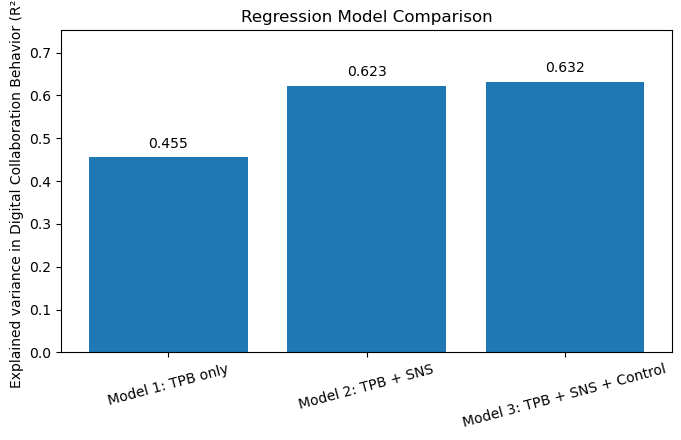

Saved: outputs_network_extended_tpb\Figure2_regression_model_comparison.png


In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = list(model_specs.keys())
r2_values = [model_summary_table.loc[model_summary_table["Model"] == m, "R²"].iloc[0] for m in labels]
ax.bar(labels, r2_values)
ax.set_ylim(0, max(r2_values) + 0.12)
ax.set_ylabel("Explained variance in Digital Collaboration Behavior (R²)")
ax.set_title("Regression Model Comparison")
ax.tick_params(axis="x", labelrotation=15)
for i, value in enumerate(r2_values):
    ax.text(i, value + 0.015, f"{value:.3f}", ha="center", va="bottom")
fig.tight_layout()
figure2_path = OUTPUT_DIR / "Figure2_regression_model_comparison.png"
fig.savefig(figure2_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", figure2_path)

## 10. Table 6 and Table 7: Mediation SEM

The final manuscript model explicitly frees the covariance between exogenous predictors:

```text
SNS ~~ years_pm_experience
```

This reproduces the manuscript Table 6 degrees of freedom, **df = 17**. Omitting this line imposes `cov(SNS, years_pm_experience) = 0`, which is an additional restriction and yields **df = 18**.

In [13]:
def mediation_sem_description(free_exogenous_covariance=True):
    desc = """
    # Measurement model
    PBC =~ pbc_access_tools_num + pbc_self_efficacy_num + pbc_time_num
    SNS =~ support_has_colleague_help_num + team_discuss_tech_num + support_colleagues_try_new_num

    # Structural mediation model
    PBC ~ SNS + years_pm_experience
    digital_collaboration_num ~ SNS + PBC + years_pm_experience
    """
    if free_exogenous_covariance:
        desc += """
    # Free covariance between exogenous predictors; this is the manuscript SEM specification.
    SNS ~~ years_pm_experience
    """
    return desc

def fit_mediation_sem(df, free_exogenous_covariance=True):
    pbc_items = CONSTRUCT_ITEMS["PBC"]
    sns_items = CONSTRUCT_ITEMS["SNS"]
    sem_vars = pbc_items + sns_items + [OUTCOME_VAR, CONTROL_VAR]
    data = df[sem_vars].apply(pd.to_numeric, errors="coerce").dropna().copy()
    model = Model(mediation_sem_description(free_exogenous_covariance=free_exogenous_covariance))
    model.fit(data)
    fit = calc_stats(model)
    estimates = model.inspect(std_est=True)
    return model, data, fit, estimates

def get_sem_r2(estimates, variable):
    std = sem_std_col(estimates)
    row = estimates[(estimates["lval"] == variable) & (estimates["op"] == "~~") & (estimates["rval"] == variable)]
    residual_var = float(row[std].iloc[0])
    return 1 - residual_var

def summarize_sem_fit(fit, estimates, n):
    return {"N": n, "chi-square": fit_value(fit, "chi2"), "df": fit_value(fit, "DoF"), "chi-square p-value": fit_value(fit, "chi2 p-value"), "CFI": fit_value(fit, "CFI"), "TLI": fit_value(fit, "TLI"), "RMSEA": fit_value(fit, "RMSEA"), "R² for PBC": get_sem_r2(estimates, "PBC"), "R² for DCB": get_sem_r2(estimates, OUTCOME_VAR)}

sem_model_no_cov, sem_data_no_cov, sem_fit_no_cov, sem_est_no_cov = fit_mediation_sem(df, free_exogenous_covariance=False)
sem_model, sem_data, sem_fit, sem_estimates = fit_mediation_sem(df, free_exogenous_covariance=True)
df_diagnostic = pd.DataFrame([
    {"SEM specification": "Without SNS ~~ years_pm_experience", **summarize_sem_fit(sem_fit_no_cov, sem_est_no_cov, len(sem_data_no_cov))},
    {"SEM specification": "With SNS ~~ years_pm_experience (manuscript)", **summarize_sem_fit(sem_fit, sem_estimates, len(sem_data))},
])
print("SEM df diagnostic:")
display(df_diagnostic[["SEM specification", "N", "chi-square", "df", "CFI", "TLI", "RMSEA", "R² for PBC", "R² for DCB"]].round(3))

fit_summary = summarize_sem_fit(sem_fit, sem_estimates, len(sem_data))
table6 = pd.DataFrame({"Fit index": list(fit_summary.keys()), "Result": list(fit_summary.values())})

def sem_path_row(estimates, hypothesis, lhs, rhs, label):
    std = sem_std_col(estimates)
    pcol = sem_p_col(estimates)
    row = estimates[(estimates["lval"] == lhs) & (estimates["op"] == "~") & (estimates["rval"] == rhs)].iloc[0]
    beta = float(row[std])
    pval = float(row[pcol]) if pcol is not None and str(row[pcol]) != "-" else np.nan
    if hypothesis.startswith("H"):
        decision = "Supported" if pval < 0.05 else "Not supported"
    else:
        decision = "Significant" if pval < 0.05 else "Not significant"
    return {"Hypothesis": hypothesis, "Path": label, "Standardized β": beta, "p-value": pval, "Decision": decision}

path_specs = [("H2", OUTCOME_VAR, "SNS", "SNS → DCB"), ("H3", "PBC", "SNS", "SNS → PBC"), ("H1c", OUTCOME_VAR, "PBC", "PBC → DCB"), ("Control", "PBC", CONTROL_VAR, "PM experience → PBC"), ("Control", OUTCOME_VAR, CONTROL_VAR, "PM experience → DCB")]
table7 = pd.DataFrame([sem_path_row(sem_estimates, *spec) for spec in path_specs])
print("Manuscript SEM specification:")
print(mediation_sem_description(free_exogenous_covariance=True))
print("Complete SEM cases:", len(sem_data))
display(table6.assign(Result=table6["Result"].map(lambda x: round(x, 3) if isinstance(x, (float, np.floating)) else x)))
display(table7.assign(**{"Standardized β": table7["Standardized β"].round(3), "p-value": table7["p-value"].map(p_value_text)}))

SEM df diagnostic:


,SEM specification,N,chi-square,df,CFI,TLI,RMSEA,R² for PBC,R² for DCB
0,Without SNS ~~ years_pm_experience,210,35.985,18.0,0.983,0.972,0.069,0.517,0.679
1,With SNS ~~ years_pm_experience (manuscript),210,31.424,17.0,0.986,0.976,0.064,0.521,0.674


Manuscript SEM specification:

    # Measurement model
    PBC =~ pbc_access_tools_num + pbc_self_efficacy_num + pbc_time_num
    SNS =~ support_has_colleague_help_num + team_discuss_tech_num + support_colleagues_try_new_num

    # Structural mediation model
    PBC ~ SNS + years_pm_experience
    digital_collaboration_num ~ SNS + PBC + years_pm_experience
    
    # Free covariance between exogenous predictors; this is the manuscript SEM specification.
    SNS ~~ years_pm_experience
    
Complete SEM cases: 210


,Fit index,Result
0,N,210.000
1,chi-square,31.424
2,df,17.000
3,chi-square p-value,0.018
4,CFI,0.986
5,TLI,0.976
6,RMSEA,0.064
7,R² for PBC,0.521
8,R² for DCB,0.674


,Hypothesis,Path,Standardized β,p-value,Decision
0,H2,SNS → DCB,0.655,< .001,Supported
1,H3,SNS → PBC,0.717,< .001,Supported
2,H1c,PBC → DCB,0.224,0.002,Supported
3,Control,PM experience → PBC,0.026,0.644,Not significant
4,Control,PM experience → DCB,-0.091,0.033,Significant


## 11. Table 8: Bootstrap composite mediation effects

This section uses construct mean scores for the bootstrap mediation confidence intervals. This matches the manuscript's bootstrap composite mediation table.

In [14]:
data_comp = pd.DataFrame({"SNS_mean": df["SNS_mean"], "PBC_mean": df["PBC_mean"], "DCB": df[OUTCOME_VAR], "PM_exp": df[CONTROL_VAR]}).dropna().copy()
mediator_model = sm.OLS(data_comp["PBC_mean"], sm.add_constant(data_comp[["SNS_mean", "PM_exp"]])).fit(cov_type="HC3")
outcome_model = sm.OLS(data_comp["DCB"], sm.add_constant(data_comp[["SNS_mean", "PBC_mean", "PM_exp"]])).fit(cov_type="HC3")

def mediation_effects(sample):
    m_model = sm.OLS(sample["PBC_mean"], sm.add_constant(sample[["SNS_mean", "PM_exp"]])).fit()
    y_model = sm.OLS(sample["DCB"], sm.add_constant(sample[["SNS_mean", "PBC_mean", "PM_exp"]])).fit()
    a = m_model.params["SNS_mean"]
    b = y_model.params["PBC_mean"]
    c_prime = y_model.params["SNS_mean"]
    indirect = a * b
    total = c_prime + indirect
    prop_mediated = indirect / total
    return a, b, c_prime, indirect, total, prop_mediated

rng = np.random.default_rng(RANDOM_SEED)
n = len(data_comp)
boot_results = []
for _ in range(N_BOOTSTRAP):
    idx = rng.integers(0, n, size=n)
    boot_sample = data_comp.iloc[idx]
    boot_results.append(mediation_effects(boot_sample))
boot_results = pd.DataFrame(boot_results, columns=["SNS → PBC", "PBC → DCB", "SNS → DCB", "SNS → PBC → DCB", "Total effect", "Proportion mediated"])
point_estimates = pd.Series(mediation_effects(data_comp), index=["SNS → PBC", "PBC → DCB", "SNS → DCB", "SNS → PBC → DCB", "Total effect", "Proportion mediated"])
table8 = pd.DataFrame({"Effect": point_estimates.index, "Estimate": point_estimates.values, "Bootstrap mean": boot_results.mean().values, "95% Bootstrap CI lower": boot_results.quantile(0.025).values, "95% Bootstrap CI upper": boot_results.quantile(0.975).values})
table8["Interpretation"] = np.where((table8["95% Bootstrap CI lower"] > 0) | (table8["95% Bootstrap CI upper"] < 0), "Significant", "Not significant")
table8.loc[table8["Effect"] == "Proportion mediated", "Interpretation"] = "Partial mediation proportion"
print("Composite mediation sample size:", n)
display(table8.round(3))

Composite mediation sample size: 210


,Effect,Estimate,Bootstrap mean,95% Bootstrap CI lower,95% Bootstrap CI upper,Interpretation
0,SNS → PBC,0.567,0.565,0.430,0.697,Significant
1,PBC → DCB,0.321,0.322,0.168,0.484,Significant
2,SNS → DCB,0.642,0.640,0.479,0.786,Significant
3,SNS → PBC → DCB,0.182,0.183,0.086,0.301,Significant
4,Total effect,0.824,0.823,0.716,0.917,Significant
5,Proportion mediated,0.221,0.224,0.102,0.375,Partial mediation proportion


## 12. Figure 3: Final empirical mediation model

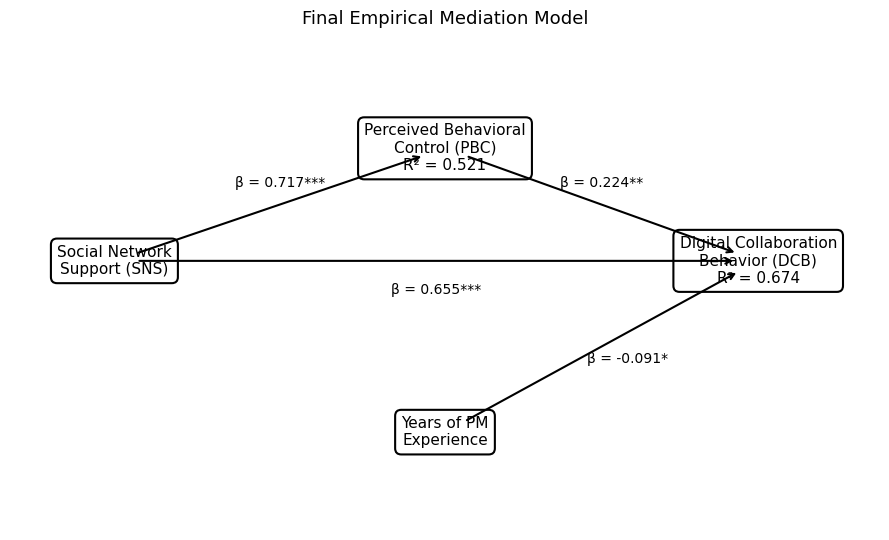

Saved: outputs_network_extended_tpb\Figure3_final_empirical_mediation_model.png


In [15]:
std = sem_std_col(sem_estimates)
def get_std_path(lhs, rhs):
    row = sem_estimates[(sem_estimates["lval"] == lhs) & (sem_estimates["op"] == "~") & (sem_estimates["rval"] == rhs)].iloc[0]
    pcol = sem_p_col(sem_estimates)
    pval = float(row[pcol]) if pcol is not None and str(row[pcol]) != "-" else np.nan
    return float(row[std]), significance_stars(pval)

sns_pbc, sns_pbc_star = get_std_path("PBC", "SNS")
pbc_dcb, pbc_dcb_star = get_std_path(OUTCOME_VAR, "PBC")
sns_dcb, sns_dcb_star = get_std_path(OUTCOME_VAR, "SNS")
pm_dcb, pm_dcb_star = get_std_path(OUTCOME_VAR, CONTROL_VAR)
r2_pbc = fit_summary["R² for PBC"]
r2_dcb = fit_summary["R² for DCB"]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.axis("off")
positions = {"SNS": (0.12, 0.55), "PBC": (0.50, 0.78), "DCB": (0.86, 0.55), "PM": (0.50, 0.20)}
box_props = dict(boxstyle="round,pad=0.4", linewidth=1.5, facecolor="white")
ax.text(*positions["SNS"], "Social Network\nSupport (SNS)", ha="center", va="center", bbox=box_props, fontsize=11)
ax.text(*positions["PBC"], f"Perceived Behavioral\nControl (PBC)\nR² = {r2_pbc:.3f}", ha="center", va="center", bbox=box_props, fontsize=11)
ax.text(*positions["DCB"], f"Digital Collaboration\nBehavior (DCB)\nR² = {r2_dcb:.3f}", ha="center", va="center", bbox=box_props, fontsize=11)
ax.text(*positions["PM"], "Years of PM\nExperience", ha="center", va="center", bbox=box_props, fontsize=11)
arrow_props = dict(arrowstyle="->", linewidth=1.5, shrinkA=18, shrinkB=18)
ax.annotate("", xy=positions["PBC"], xytext=positions["SNS"], arrowprops=arrow_props)
ax.text(0.31, 0.71, f"β = {sns_pbc:.3f}{sns_pbc_star}", ha="center", va="center", fontsize=10)
ax.annotate("", xy=positions["DCB"], xytext=positions["PBC"], arrowprops=arrow_props)
ax.text(0.68, 0.71, f"β = {pbc_dcb:.3f}{pbc_dcb_star}", ha="center", va="center", fontsize=10)
ax.annotate("", xy=positions["DCB"], xytext=positions["SNS"], arrowprops=arrow_props)
ax.text(0.49, 0.49, f"β = {sns_dcb:.3f}{sns_dcb_star}", ha="center", va="center", fontsize=10)
ax.annotate("", xy=positions["DCB"], xytext=positions["PM"], arrowprops=arrow_props)
ax.text(0.71, 0.35, f"β = {pm_dcb:.3f}{pm_dcb_star}", ha="center", va="center", fontsize=10)
ax.set_title("Final Empirical Mediation Model", fontsize=13, pad=12)
fig.tight_layout()
figure3_path = OUTPUT_DIR / "Figure3_final_empirical_mediation_model.png"
fig.savefig(figure3_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", figure3_path)

## 13. Export manuscript tables and figures

In [16]:
output_excel = OUTPUT_DIR / "network_extended_tpb_manuscript_tables.xlsx"
with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    table1.to_excel(writer, sheet_name="Table 1 profile", index=False)
    table1_full_profile.to_excel(writer, sheet_name="Full respondent profile", index=False)
    if "job_title" in df.columns:
        df[["job_title", "role_category"]].to_excel(writer, sheet_name="Role coding audit", index=False)
    if "training_details" in df.columns:
        training_cols = [c for c in ["prior_formal_training_en", "training_details", "prior_training_category"] if c in df.columns]
        df[training_cols].to_excel(writer, sheet_name="Training coding audit", index=False)
    table2_display.to_excel(writer, sheet_name="Table 2 descriptives", index=False)
    table3.to_excel(writer, sheet_name="Table 3 reliability", index=False)
    table4_numeric.to_excel(writer, sheet_name="Table 4 correlations")
    table4_formatted.to_excel(writer, sheet_name="Table 4 formatted")
    table5.to_excel(writer, sheet_name="Table 5 regression", index=False)
    model_summary_table.to_excel(writer, sheet_name="Regression model summary", index=False)
    detailed_regression_table.to_excel(writer, sheet_name="Regression details", index=False)
    vif_model3.to_excel(writer, sheet_name="VIF Model 3", index=False)
    df_diagnostic.to_excel(writer, sheet_name="SEM df diagnostic", index=False)
    table6.to_excel(writer, sheet_name="Table 6 SEM fit", index=False)
    table7.to_excel(writer, sheet_name="Table 7 SEM paths", index=False)
    table8.to_excel(writer, sheet_name="Table 8 mediation", index=False)
    sem_estimates.to_excel(writer, sheet_name="SEM estimates", index=False)
    boot_results.to_excel(writer, sheet_name="Bootstrap raw", index=False)
print("Saved Excel workbook:", output_excel)
print("Saved figures:")
print(" -", figure2_path)
print(" -", figure3_path)


Saved Excel workbook: outputs_network_extended_tpb\network_extended_tpb_manuscript_tables.xlsx
Saved figures:
 - outputs_network_extended_tpb\Figure2_regression_model_comparison.png
 - outputs_network_extended_tpb\Figure3_final_empirical_mediation_model.png


## 14. Optional: manuscript consistency checks

Use this cell after running the notebook to compare key outputs against the values currently reported in the manuscript. Small differences can occur if the spreadsheet data changes, if missing values are edited, or if package versions differ.

In [17]:
expected = {
    "Table 5 Model 1 R²": 0.455,
    "Table 5 Model 2 R²": 0.623,
    "Table 5 Model 3 R²": 0.632,
    "Table 6 SEM df": 17,
    "Table 6 SEM CFI": 0.986,
    "Table 6 SEM TLI": 0.976,
    "Table 6 SEM RMSEA": 0.064,
}
observed = {
    "Table 5 Model 1 R²": model_summary_table.loc[0, "R²"],
    "Table 5 Model 2 R²": model_summary_table.loc[1, "R²"],
    "Table 5 Model 3 R²": model_summary_table.loc[2, "R²"],
    "Table 6 SEM df": fit_summary["df"],
    "Table 6 SEM CFI": fit_summary["CFI"],
    "Table 6 SEM TLI": fit_summary["TLI"],
    "Table 6 SEM RMSEA": fit_summary["RMSEA"],
}
consistency = pd.DataFrame({"Statistic": observed.keys(), "Observed": observed.values(), "Expected manuscript value": [expected[k] for k in observed.keys()]})
consistency["Difference"] = consistency["Observed"] - consistency["Expected manuscript value"]
display(consistency.round(4))

,Statistic,Observed,Expected manuscript value,Difference
0,Table 5 Model 1 R²,0.4553,0.455,0.0003
1,Table 5 Model 2 R²,0.6232,0.623,0.0002
2,Table 5 Model 3 R²,0.6321,0.632,0.0001
3,Table 6 SEM df,17.0000,17.000,0.0000
4,Table 6 SEM CFI,0.9860,0.986,0.0000
5,Table 6 SEM TLI,0.9762,0.976,0.0002
6,Table 6 SEM RMSEA,0.0637,0.064,-0.0003
